In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import *
from modules.CliffsDelta import cliffsDelta

In [2]:
os.getcwd()

'/home/cs/grad/opumni/Research/Tangled'

# For one project

In [3]:
project_name = "sonarqube"
noise_free_dir = f"./data/NoiseFreeDataset/{project_name}.csv"
noisy_dir = f"./data/NoisyDataset/{project_name}.csv"

cols = ["SLOCStandard", "Readability", "McCabe", "totalFanOut", "MaintainabilityIndex"]

In [4]:
noise_free_df = pd.read_csv(noise_free_dir)
noise_free_buggy = noise_free_df[noise_free_df["Detection"] == "Buggy"][cols]
noise_free_notbuggy = noise_free_df[noise_free_df["Detection"] == "NotBuggy"][cols]

noisy_df = pd.read_csv(noisy_dir)
noisy_buggy = noisy_df[noisy_df["Decision"] == "Buggy"][cols]
noisy_notbuggy = noisy_df[noisy_df["Decision"] == "NotBuggy"][cols]

noise_free_buggy["Group"] = "Noise-Free Buggy"
noise_free_notbuggy["Group"] = "Noise-Free NotBuggy"
noisy_buggy["Group"] = "Noisy Buggy"
noisy_notbuggy["Group"] = "Noisy NotBuggy"

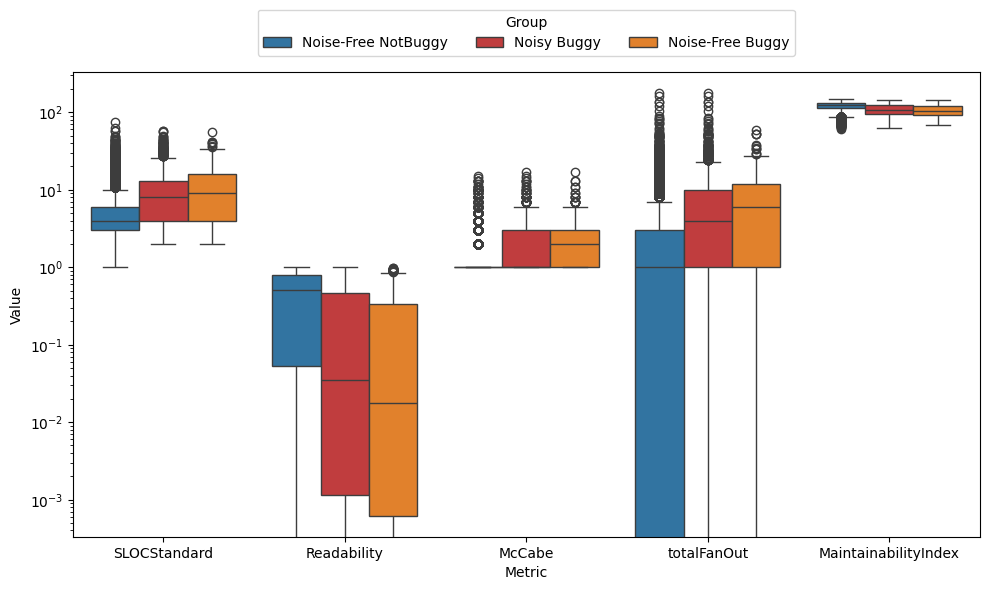

In [ ]:
combined_df = pd.concat([noise_free_notbuggy, noisy_buggy, noise_free_buggy])
long_df = combined_df.melt(id_vars='Group', var_name='Metric', value_name='Value')

custom_palette = {
    'Noise-Free Buggy': '#ff7f0e',        # red
    'Noise-Free NotBuggy': '#1f77b4',    # blue
    'Noisy Buggy': '#d62728',         # orange
    'Noisy NotBuggy': '#2ca02c'      # green
}

plt.figure(figsize=(10, 6))
sns.boxplot(data=long_df, x='Metric', y='Value', hue='Group', palette=custom_palette)
plt.yscale('log')
plt.ylabel('Value')
plt.legend(title='Group', loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=4)
plt.tight_layout()
plt.show()

### Wilcoxon rank sum test - a single project

In [6]:
results = []
for col in cols:
    z_stat, p_value = ranksums(noisy_buggy[col], noise_free_buggy[col])
    is_diff = p_value < 0.05
    results.append({'column': col, 'z_stat': z_stat, 'p_value': p_value, 'is_difference': is_diff})

stat_results_df = pd.DataFrame(results)

stat_results_df

,column,z_stat,p_value,is_difference
0,SLOCStandard,-3.324183,0.000887,True
1,Readability,1.563009,0.118050,False
2,McCabe,-4.220076,0.000024,True
3,totalFanOut,-2.596801,0.009410,True
4,MaintainabilityIndex,3.262063,0.001106,True


## Cliff's Delta

In [7]:
results = []
for col in cols:
    d, size = cliffsDelta(noisy_buggy[col], noise_free_buggy[col])
    results.append({'column': col, 'd': p_value, 'effect_size': size})

stat_results_df = pd.DataFrame(results)

stat_results_df


,column,d,effect_size
0,SLOCStandard,0.001106,negligible
1,Readability,0.001106,negligible
2,McCabe,0.001106,small
3,totalFanOut,0.001106,negligible
4,MaintainabilityIndex,0.001106,negligible


## supplimentary results

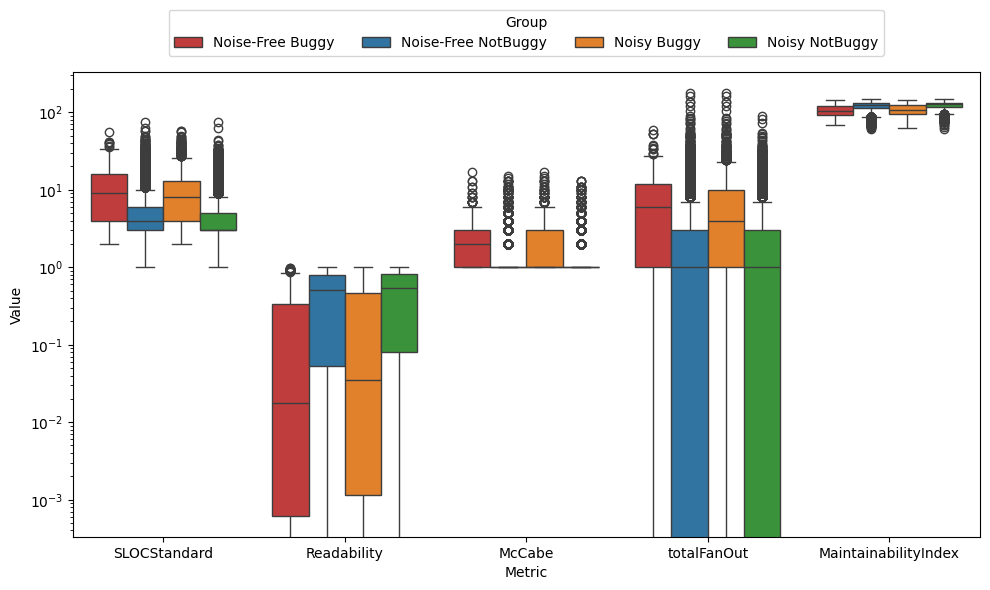

In [ ]:
combined_df = pd.concat([noise_free_buggy, noise_free_notbuggy, noisy_buggy, noisy_notbuggy])
long_df = combined_df.melt(id_vars='Group', var_name='Metric', value_name='Value')

custom_palette = {
    'Noise-Free Buggy': '#d62728',        # red
    'Noise-Free NotBuggy': '#1f77b4',    # blue
    'Noisy Buggy': '#ff7f0e',         # orange
    'Noisy NotBuggy': '#2ca02c'      # green
}

plt.figure(figsize=(10, 6))
sns.boxplot(data=long_df, x='Metric', y='Value', hue='Group', palette=custom_palette)
plt.yscale('log') 
plt.ylabel('Value')
plt.legend(title='Group', loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=4)
plt.tight_layout()
plt.show()

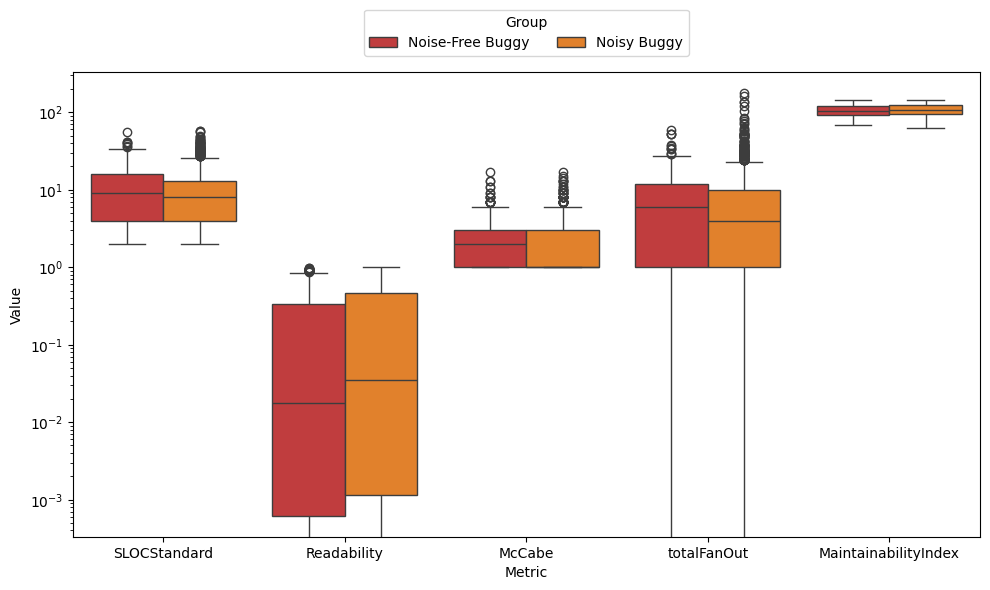

In [ ]:
combined_df = pd.concat([noise_free_buggy, noisy_buggy])
long_df = combined_df.melt(id_vars='Group', var_name='Metric', value_name='Value')

custom_palette = {
    'Noise-Free Buggy': '#d62728',        # red
    'Noise-Free NotBuggy': '#1f77b4',    # blue
    'Noisy Buggy': '#ff7f0e',         # orange
    'Noisy NotBuggy': '#2ca02c'      # green
}

plt.figure(figsize=(10, 6))
sns.boxplot(data=long_df, x='Metric', y='Value', hue='Group', palette=custom_palette)
plt.yscale('log') 
plt.ylabel('Value')
plt.legend(title='Group', loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=4)
plt.tight_layout()
plt.show()


# For all projects

In [2]:
noise_free_dir = f"./data/NoiseFreeDataset/"
noisy_dir = f"./data/NoisyDataset/"

cols = ["SLOCStandard", "Readability", "McCabe", "totalFanOut", "MaintainabilityIndex"]

In [3]:
def load_csvs_from_dir(directory):
    all_files = [os.path.join(directory, f) for f in os.listdir(directory) if f.endswith(".csv")]
    df_list = [pd.read_csv(file) for file in all_files]
    return pd.concat(df_list, ignore_index=True)

# Load and process noise-free CSVs
noise_free_df = load_csvs_from_dir(noise_free_dir)
noise_free_buggy = noise_free_df[noise_free_df["Detection"] == "Buggy"][cols].copy()
noise_free_notbuggy = noise_free_df[noise_free_df["Detection"] == "NotBuggy"][cols].copy()

# Load and process noisy CSVs
noisy_df = load_csvs_from_dir(noisy_dir)
noisy_buggy = noisy_df[noisy_df["Decision"] == "Buggy"][cols].copy()
noisy_notbuggy = noisy_df[noisy_df["Decision"] == "NotBuggy"][cols].copy()

# Add group labels
noise_free_buggy["Group"] = "Noise-Free Buggy"
noise_free_notbuggy["Group"] = "Noise-Free NotBuggy"
noisy_buggy["Group"] = "Noisy Buggy"
noisy_notbuggy["Group"] = "Noisy NotBuggy"

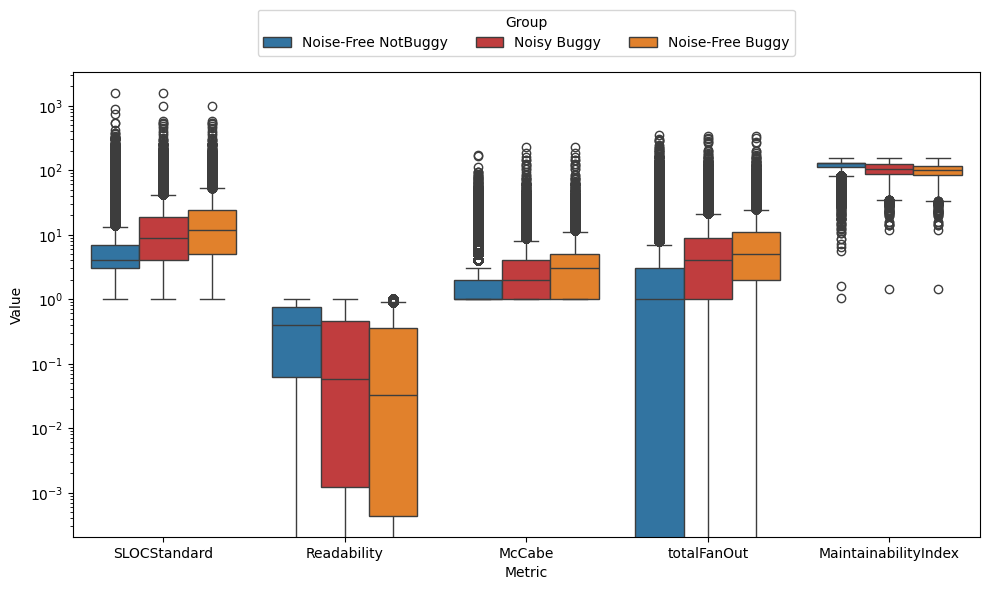

In [ ]:
combined_df = pd.concat([noise_free_notbuggy, noisy_buggy, noise_free_buggy])
long_df = combined_df.melt(id_vars='Group', var_name='Metric', value_name='Value')

custom_palette = {
    'Noise-Free Buggy': '#ff7f0e',        # red
    'Noise-Free NotBuggy': '#1f77b4',    # blue
    'Noisy Buggy': '#d62728',         # orange
    'Noisy NotBuggy': '#2ca02c'      # green
}

plt.figure(figsize=(10, 6))
sns.boxplot(data=long_df, x='Metric', y='Value', hue='Group', palette=custom_palette)
plt.yscale('log')
plt.ylabel('Value')
plt.legend(title='Group', loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=4)
plt.tight_layout()
plt.show()

## Wilcoxon rank sum test

### All methods from all projects

In [5]:
# Load and process noise-free CSVs
noise_free_df = load_csvs_from_dir(noise_free_dir)
noise_free_buggy = noise_free_df[noise_free_df["Detection"] == "Buggy"][cols].copy()

# Load and process noisy CSVs
noisy_df = load_csvs_from_dir(noisy_dir)
noisy_buggy = noisy_df[noisy_df["Decision"] == "Buggy"][cols].copy()

results = []
for col in cols:
    z_stat, p_value = ranksums(noisy_buggy[col], noise_free_buggy[col])
    is_diff = p_value < 0.05
    results.append({'column': col, 'z_stat': z_stat, 'p_value': p_value, 'is_different': is_diff})

stat_results_df = pd.DataFrame(results)

stat_results_df

,column,z_stat,p_value,is_different
0,SLOCStandard,-20.623562,1.686712e-94,True
1,Readability,11.983838,4.318555e-33,True
2,McCabe,-20.806879,3.749783e-96,True
3,totalFanOut,-16.451448,8.188662e-61,True
4,MaintainabilityIndex,20.348620,4.775287e-92,True


### Individual project

In [6]:
results = []

all_files = [f for f in os.listdir(noise_free_dir) if f.endswith(".csv")]

method_count = []

for file in all_files:
    noisy_buggy = pd.read_csv(os.path.join(noisy_dir, file))
    noisy_buggy = noisy_buggy[noisy_buggy["Decision"] == "Buggy"][cols].copy()
    
    noise_free_buggy = pd.read_csv(os.path.join(noise_free_dir, file))
    noise_free_buggy = noise_free_buggy[noise_free_buggy["Detection"] == "Buggy"][cols].copy()


    res = {"Project": file.replace('.csv', '')}
    res["#Methods"] = len(noisy_buggy) + len(noise_free_buggy)

    for col in cols:
        z_stat, p_value = ranksums(noisy_buggy[col], noise_free_buggy[col])
        is_diff = p_value < 0.05
        res[col] = is_diff
    results.append(res)

stat_results_df = pd.DataFrame(results)
stat_results_df

,Project,#Methods,SLOCStandard,Readability,McCabe,totalFanOut,MaintainabilityIndex
0,spring-boot,201,False,True,False,True,True
1,guava,838,True,False,True,True,True
2,pmd,984,True,False,True,True,True
3,hbase,1513,False,False,False,False,False
4,ant,470,False,False,False,False,False
5,lucene-solr,1264,True,True,True,True,True
6,jna,242,False,False,False,False,False
7,spring-framework,370,False,True,False,False,False
8,sonarqube,1728,True,False,True,True,True
9,voldemort,625,False,False,False,False,False


In [7]:
true_percentages_all = stat_results_df.drop(["Project", "#Methods"], axis=1).mean() * 100
true_percentages_df_all = true_percentages_all.reset_index()
true_percentages_df_all.columns = ['column', 'All']
true_percentages_df_all = true_percentages_df_all.set_index('column').T

true_percentages_t20 = stat_results_df.sort_values(by=["#Methods"], ascending=False).head(20).drop(["Project", "#Methods"], axis=1).mean() * 100
true_percentages_df_t20 = true_percentages_t20.reset_index()
true_percentages_df_t20.columns = ['column', 'Top 20']
true_percentages_df_t20 = true_percentages_df_t20.set_index('column').T

pd.concat([true_percentages_df_all, true_percentages_df_t20]).round(2)

column,SLOCStandard,Readability,McCabe,totalFanOut,MaintainabilityIndex
All,44.9,36.73,44.9,44.9,48.98
Top 20,75.0,55.00,75.0,75.0,80.00


## Cliff's Delta

### All methods from all projects

In [8]:
# Load and process noise-free CSVs
noise_free_df = load_csvs_from_dir(noise_free_dir)
noise_free_buggy = noise_free_df[noise_free_df["Detection"] == "Buggy"][cols].copy()

# Load and process noisy CSVs
noisy_df = load_csvs_from_dir(noisy_dir)
noisy_buggy = noisy_df[noisy_df["Decision"] == "Buggy"][cols].copy()

results = []
for col in cols:
    d, size = cliffsDelta(noisy_buggy[col], noise_free_buggy[col])
    results.append({'column': col, 'd': p_value, 'effect_size': size})

stat_results_df = pd.DataFrame(results)

stat_results_df


,column,d,effect_size
0,SLOCStandard,0.000341,negligible
1,Readability,0.000341,negligible
2,McCabe,0.000341,negligible
3,totalFanOut,0.000341,negligible
4,MaintainabilityIndex,0.000341,negligible


### Individual project

In [9]:
results = []
all_files = [f for f in os.listdir(noise_free_dir) if f.endswith(".csv")]
method_count = []

for file in all_files:
    noisy_buggy = pd.read_csv(os.path.join(noisy_dir, file))
    noisy_buggy = noisy_buggy[noisy_buggy["Decision"] == "Buggy"][cols].copy()
    
    noise_free_buggy = pd.read_csv(os.path.join(noise_free_dir, file))
    noise_free_buggy = noise_free_buggy[noise_free_buggy["Detection"] == "Buggy"][cols].copy()


    res = {"Project": file.replace('.csv', '')}
    res["#Methods"] = len(noisy_buggy) + len(noise_free_buggy)

    for col in cols:
        d, size = cliffsDelta(noisy_buggy[col], noise_free_buggy[col])
        res[col] = size
    results.append(res)

stat_results_df = pd.DataFrame(results)

stat_results_df

,Project,#Methods,SLOCStandard,Readability,McCabe,totalFanOut,MaintainabilityIndex
0,spring-boot,201,small,small,negligible,small,small
1,guava,838,negligible,negligible,negligible,negligible,negligible
2,pmd,984,small,negligible,negligible,small,small
3,hbase,1513,negligible,negligible,negligible,negligible,negligible
4,ant,470,negligible,negligible,negligible,negligible,negligible
5,lucene-solr,1264,small,negligible,small,negligible,small
6,jna,242,negligible,negligible,negligible,negligible,negligible
7,spring-framework,370,negligible,negligible,negligible,negligible,negligible
8,sonarqube,1728,negligible,negligible,small,negligible,negligible
9,voldemort,625,negligible,negligible,negligible,negligible,negligible


In [10]:
# All projects
res = []
for col in cols:
    percentage = pd.DataFrame(stat_results_df[col].value_counts(normalize=True) * 100)
    res.append({
        'column': col,
        'negligible': percentage.loc["negligible"]["proportion"] if "negligible" in percentage.index else 0,
        'small': percentage.loc["small"]["proportion"] if "small" in percentage.index else 0,
        'medium': percentage.loc["medium"]["proportion"] if "medium" in percentage.index else 0,
        'large': percentage.loc["large"]["proportion"] if "large" in percentage.index else 0,
    })
pd.DataFrame(res).round(2)

,column,negligible,small,medium,large
0,SLOCStandard,69.39,30.61,0,0
1,Readability,89.80,10.20,0,0
2,McCabe,65.31,34.69,0,0
3,totalFanOut,67.35,32.65,0,0
4,MaintainabilityIndex,67.35,32.65,0,0


In [11]:
# Top 20 projects by number of methods
res = []
top20 = stat_results_df.sort_values(by=["#Methods"], ascending=False).head(20)
for col in cols:
    percentage = pd.DataFrame(top20[col].value_counts(normalize=True) * 100)
    res.append({
        'column': col,
        'negligible': percentage.loc["negligible"]["proportion"] if "negligible" in percentage.index else 0,
        'small': percentage.loc["small"]["proportion"] if "small" in percentage.index else 0,
        'medium': percentage.loc["medium"]["proportion"] if "medium" in percentage.index else 0,
        'large': percentage.loc["large"]["proportion"] if "large" in percentage.index else 0,
    })
pd.DataFrame(res).round(2)

,column,negligible,small,medium,large
0,SLOCStandard,65.0,35.0,0,0
1,Readability,95.0,5.0,0,0
2,McCabe,60.0,40.0,0,0
3,totalFanOut,65.0,35.0,0,0
4,MaintainabilityIndex,65.0,35.0,0,0
